In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('Data/Final_Data.csv')

In [3]:
data = data.drop(columns=["SiteKey"])
data.shape

(1599443, 36)

In [ ]:
X_now = data.drop(columns=[
    "CapacityFactor",
    "Target_15min","Target_1h","Target_3h",
    "Residual_15min","Residual_1h","Residual_3h",
    "Residual_now",
    "SolarGeneration"
])

y_now = data["Residual_now"]
true_now = data["CapacityFactor"]

n_splits = 5
split_size = int(len(X_now) / (n_splits + 1))
max_train_size = 1599443

mae_model_now = 0
mae_naive_now = 0
r2_now = 0

for i in range(n_splits):
    train_end = split_size * (i+1)
    test_end = split_size * (i+2)
    train_start = max(0, train_end - max_train_size)

    X_train = X_now.iloc[train_start:train_end]
    X_test = X_now.iloc[train_end:test_end]

    y_train = y_now.iloc[train_start:train_end]
    y_test = y_now.iloc[train_end:test_end]

    true_test = true_now.iloc[train_end:test_end]

    lag_test = X_test["Lag_1"].values

    model = RandomForestRegressor(
        n_estimators=400,
        max_depth=18,
        n_jobs=2,
        random_state=42
    )

    model.fit(X_train, y_train)
    residual_pred = model.predict(X_test)

    pred = lag_test + residual_pred

    mae_model_now += mean_absolute_error(true_test, pred)
    mae_naive_now += mean_absolute_error(true_test, lag_test)
    r2_now += r2_score(true_test, pred)

mae_model_now /= n_splits
mae_naive_now /= n_splits
r2_now /= n_splits

print("\nCURRENT PREDICTION")
print("Naive MAE:", mae_naive_now)
print("Model MAE:", mae_model_now)
print("R2:", r2_now)


CURRENT PREDICTION
Naive MAE: 0.00891871835001148
Model MAE: 0.006822727499456246
R2: 0.9518440953202811


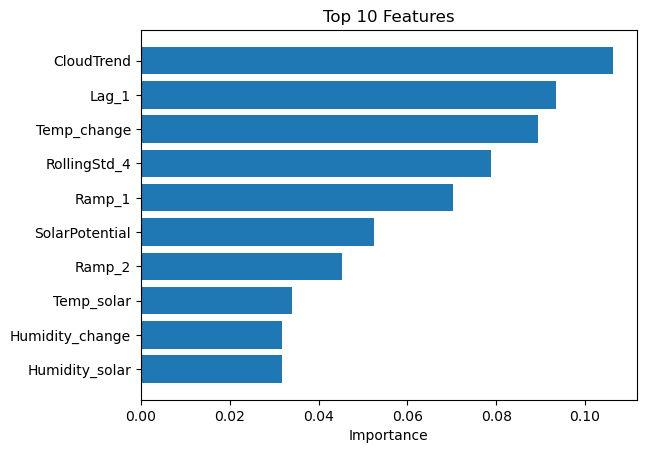

In [14]:
importance_now = pd.DataFrame({
    "Feature": X_now.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)
 
plt.figure()
plt.barh(importance_now["Feature"][:10][::-1], importance_now["Importance"][:10][::-1])
plt.title(f"Top 10 Features")
plt.xlabel("Importance")
plt.show()

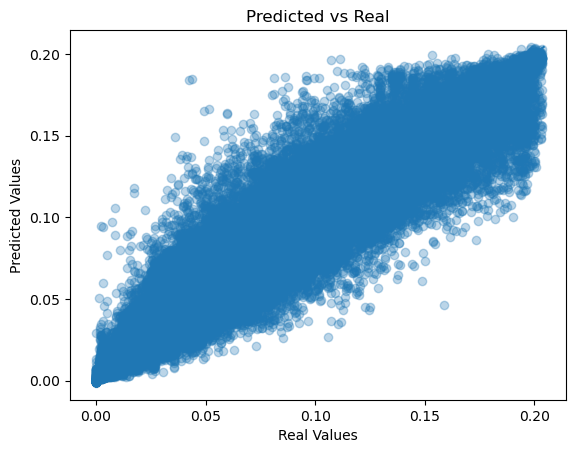

In [ ]:
y_true_plot = true_test.values
y_pred_plot = pred

plt.figure()
plt.scatter(y_true_plot, y_pred_plot, alpha=0.3)

plt.xlabel("Real Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Real")

min_val = min(y_true_plot.min(), y_pred_plot.min())
max_val = max(y_true_plot.max(), y_pred_plot.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

In [18]:
X = data.drop(columns=[
    "CapacityFactor",
    "Target_15min","Target_1h","Target_3h",
    "Residual_15min","Residual_1h","Residual_3h",
    "SolarGeneration"
])

Y = data[["Residual_15min", "Residual_1h", "Residual_3h"]]
Y_true = data[["Target_15min", "Target_1h", "Target_3h"]]

n_splits = 5
split_size = int(len(X) / (n_splits + 1))
max_train_size = 1599443

mae_model = np.zeros(3)
mae_naive = np.zeros(3)
r2_scores = np.zeros(3)

for i in range(n_splits):
    train_end = split_size * (i+1)
    test_end = split_size * (i+2)
    train_start = max(0, train_end - max_train_size)

    X_train = X.iloc[train_start:train_end]
    X_test = X.iloc[train_end:test_end]

    Y_train = Y.iloc[train_start:train_end]
    Y_test = Y.iloc[train_end:test_end]

    true_test = Y_true.iloc[train_end:test_end]

    lag_test_15 = X_test["Lag_1"].values
    lag_test_1h = X_test["Lag_2"].values
    lag_test_3h = X_test["Lag_3"].values
    lag_tests = [lag_test_15, lag_test_1h, lag_test_3h]

    model = MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=400,
            max_depth=18,
            n_jobs=6,
            random_state=42
        )
    )

    model.fit(X_train, Y_train)
    residual_pred = model.predict(X_test)

    pred = np.zeros_like(residual_pred)

    for h in range(3):
        pred[:, h] = lag_tests[h] + residual_pred[:, h]

    for h in range(3):
        mae_model[h] += mean_absolute_error(true_test.iloc[:, h], pred[:, h])
        mae_naive[h] += mean_absolute_error(true_test.iloc[:, h], lag_tests[h])
        r2_scores[h] += r2_score(true_test.iloc[:, h], pred[:, h])

mae_model /= n_splits
mae_naive /= n_splits
r2_scores /= n_splits

horizons = ["15 min","1 hour","3 hour"]

for i, h in enumerate(horizons):
    print("\nHorizon:", h)
    print("Naive MAE:", mae_naive[i])
    print("Model MAE:", mae_model[i])
    print("R2:", r2_scores[i])


Horizon: 15 min
Naive MAE: 0.013283456971665514
Model MAE: 0.007276260782023631
R2: 0.9493398256501567

Horizon: 1 hour
Naive MAE: 0.025374984928098875
Model MAE: 0.01600221474073025
R2: 0.821630074068981

Horizon: 3 hour
Naive MAE: 0.04857314903658821
Model MAE: 0.025506793995617803
R2: 0.6135750333533906


In [19]:
horizons = ["15 min","1 hour","3 hour"]

for i, h in enumerate(horizons):
    rf_model = model.estimators_[i]
    importance = rf_model.feature_importances_

    feat_imp = pd.DataFrame({
        "Feature": X.columns,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)

    print(f"\n=== TOP FEATURES: {h} ===")
    print(feat_imp.head(30))


=== TOP FEATURES: 15 min ===
                Feature  Importance
27         Residual_now    0.540580
18                Lag_1    0.039490
21               Ramp_1    0.037858
25      CloudinessIndex    0.035717
26           CloudTrend    0.035572
15          Temp_change    0.033323
23         RollingStd_4    0.024384
22               Ramp_2    0.021815
11       SolarPotential    0.020779
7              Hour_sin    0.015855
20                Lag_3    0.015492
16      Humidity_change    0.014605
10              Day_cos    0.014091
13       Humidity_solar    0.013183
2   DewPointTemperature    0.013057
9               Day_sin    0.013009
12           Temp_solar    0.012532
19                Lag_2    0.012288
24          CF_smooth_4    0.011771
0   ApparentTemperature    0.011222
14           Wind_solar    0.010110
3      RelativeHumidity    0.009546
6           WindDir_cos    0.009100
5           WindDir_sin    0.008544
17          Wind_change    0.008488
1        AirTemperature    0.00840

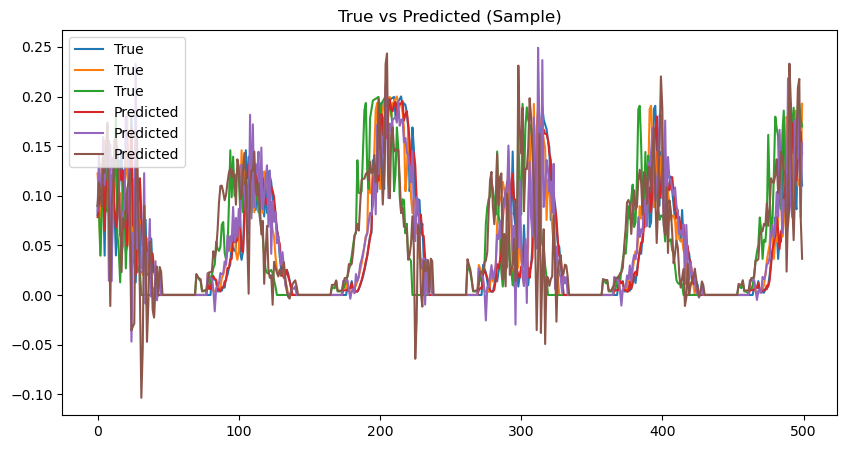

In [22]:
plt.figure(figsize=(10,5))
plt.plot(true_test.values[:500], label="True")
plt.plot(pred[:500], label="Predicted")
plt.legend()
plt.title("True vs Predicted (Sample)")
plt.show()

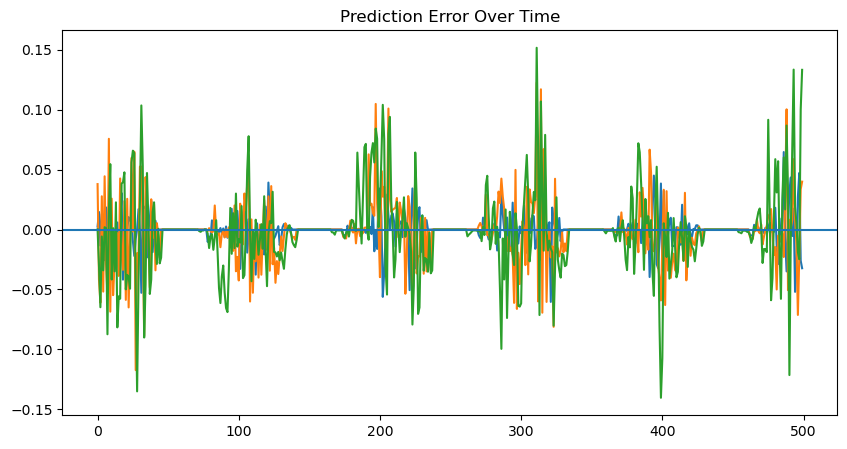

In [21]:
errors = true_test.values - pred

plt.figure(figsize=(10,5))
plt.plot(errors[:500])
plt.title("Prediction Error Over Time")
plt.axhline(0)
plt.show()